In [113]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [114]:
X,y = make_blobs(
    n_samples=300,
    n_features=2,
    centers=4,
    cluster_std=2,
    random_state=42
)

In [115]:
import  numpy as np


X= np.transpose(X)

In [116]:
import pandas as pd

df = pd.DataFrame({
    "f1":X[0],
    "f2":X[1],
    "cluster":y
})

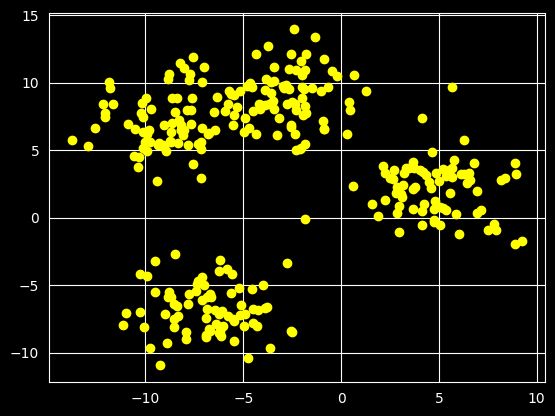

In [117]:
import matplotlib.pyplot as plt

plt.scatter(df["f1"] ,df["f2"],color="yellow")

In [118]:
# Elbow method plot
from sklearn.cluster import KMeans


k_values = np.arange(1,11)
inertias = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)

    kmeans.fit(df[['f1','f2']])

    inertias.append(kmeans.inertia_)




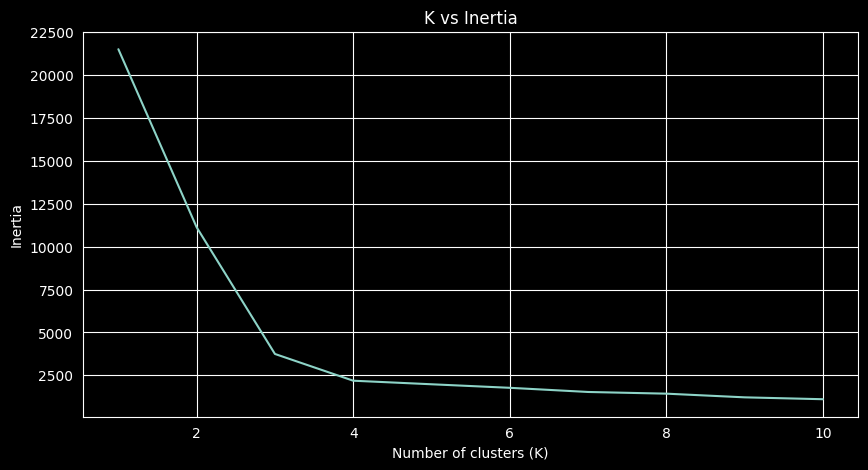

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(k_values,inertias)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("K vs Inertia")
plt.show()

In [120]:
kmeans = KMeans(n_clusters=4 , random_state=42)


df["predicted"] = kmeans.fit_predict(df[['f1','f2']])



In [121]:
from sklearn.metrics import silhouette_score,adjusted_rand_score


silhoutte = silhouette_score(df[['f1','f2']],kmeans.labels_)
rand_score = adjusted_rand_score(df['cluster'],kmeans.labels_)

In [122]:
print("Silhouette Score: ",silhoutte)
print("Adjusted Rand Score: ",rand_score)

Silhouette Score:  0.6000347806038386
Adjusted Rand Score:  0.9400820916124457


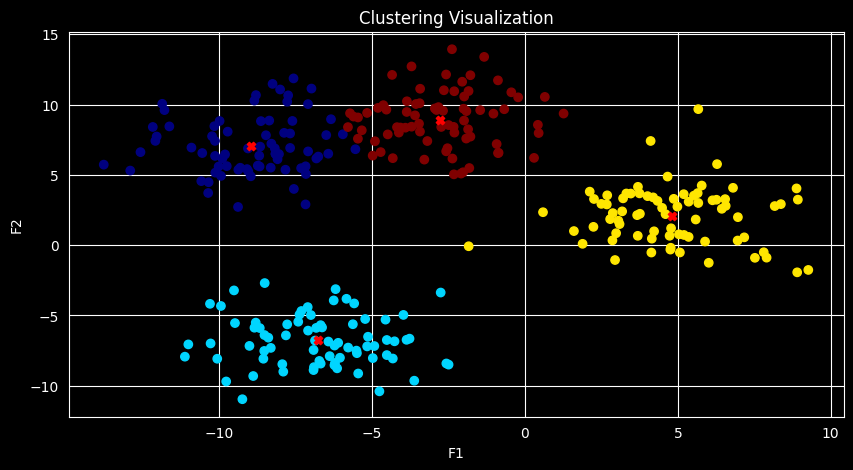

In [129]:
plt.figure(figsize=(10,5))
plt.scatter(df["f1"] ,df["f2"],c=df['predicted'] , cmap='jet')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1] , marker='X' , color='red')
plt.xlabel("F1")
plt.ylabel("F2")
plt.title("Clustering Visualization")

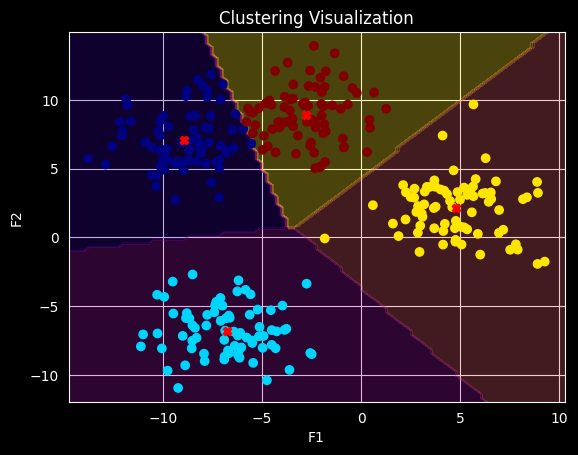

In [131]:
from sklearn.inspection import DecisionBoundaryDisplay

DecisionBoundaryDisplay.from_estimator(
    kmeans , df[['f1','f2']] , response_method='predict',alpha=0.3,cmap='plasma'
)
plt.scatter(df["f1"] ,df["f2"],c=df['predicted'] , cmap='jet')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1] , marker='X' , color='red')
plt.xlabel("F1")
plt.ylabel("F2")
plt.title("Clustering Visualization")
